# Day 10 — DFW Hospital Pricing: price by line of business

**Goal:** pivot from building the classifier to the actual pricing analysis. Use the v3 classifier as the substrate to measure how negotiated prices vary across payer line of business (LOB) and across the five DFW hospitals.

**This notebook (Day 10, Step 1):**
1. Connect to each hospital's parsed DuckDB and pull aggregated rates for the pilot procedure (CPT **73721**, lower-extremity-joint MRI).
2. Concatenate across hospitals and apply the v3 classifier (`add_lob_v3`).
3. **Profile** the result — row counts, LOB mix, rate methodology, billing class, and the in-file Medicare denominator — *before* computing any ratio.

Step 2 (commercial-to-Medicare ratio + by-LOB multiples) is filled in once Step 1 looks clean.

In [2]:

import sys
from pathlib import Path
import duckdb
import pandas as pd


ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "src").exists() and (ROOT / "data").exists():
        break
    ROOT = ROOT.parent
assert (ROOT / "src" / "queries.py").exists(), f"Couldn't find src/queries.py from {Path.cwd()}"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RAW = ROOT / "data" / "raw"
print("Project root:", ROOT)
print("Raw DBs dir :", RAW)

from src.queries import query_procedure_rates_agg, add_lob_v3

Project root: c:\Users\kedha\Documents\dfw-hospital-pricing
Raw DBs dir : c:\Users\kedha\Documents\dfw-hospital-pricing\data\raw


## Step 1 — Build the rate table for CPT 73721 across all five hospitals

In [3]:

HOSPITAL_DBS = {
    "Baylor":    "baylor_university_medical_center-69947_parsed.duckdb",
    "Methodist": "methodist_dallas_medical_center-6000b_parsed.duckdb",
    "Parkland":  "parkland_health-6e88d_parsed.duckdb",
    "THP":       "texas_health_presbyterian_hospital_plano-6ad81_parsed.duckdb",
    "MCA":       "medical_city_alliance_hospital-77912_parsed.duckdb",
}

CODE, SETTING = "73721", "outpatient"  

frames, missing = [], []
for hosp, fname in HOSPITAL_DBS.items():
    path = RAW / fname
    if not path.exists():
        missing.append(fname); continue
    con = duckdb.connect(str(path), read_only=True)
    try:
        d = query_procedure_rates_agg(con, CODE, SETTING)
        d.insert(0, "hospital", hosp)
        frames.append(d)
        print(f"{hosp:10s} {len(d):3d} rows")
    except Exception as e:
        print(f"{hosp:10s} ERROR: {e}")
    finally:
        con.close()
if missing:
    print("MISSING FILES:", missing)

all_v3 = add_lob_v3(pd.concat(frames, ignore_index=True))
print(f"\nTOTAL rows: {len(all_v3)} across {all_v3['hospital'].nunique()} hospitals")
all_v3.head()

Baylor      45 rows
Methodist   82 rows
Parkland    65 rows
THP         40 rows
MCA         46 rows

TOTAL rows: 278 across 5 hospitals


,hospital,payer_name,plan_name,payer_group,payer_type,methodology_normalized,billing_class_normalized,n_charge_ids,dollar_rate,dollar_min,dollar_max,pct_rate,gross_min,gross_max,descriptions,lob,lob_rule
0,Baylor,Baylor Scott & White Health Plan,BSW Plus - Large Group/BSW Premier Direct to E...,Other,Other,fee schedule,facility,4,2056.72,2056.72,2056.72,NaN,3409.3,3409.3,HC MR LWR EXT JT WO CM LT | HC MR LWR EXT JT W...,employer_captive,payer_name_employer_captive
1,Baylor,HealthSmart,Preferred Network,Other,Other,percent of total billed charges,facility,4,2556.98,2556.98,2556.98,NaN,3409.3,3409.3,HC MR LWR EXT JT WO CM LT | HC MRI EXT LOWER J...,tpa_self_funded,payer_name_tpa
2,Baylor,American Health Plan,Medicare Advantage,Other,Other,fee schedule,facility,4,235.30,235.30,235.30,NaN,3409.3,3409.3,HC MR LWR EXT JT WO CM LT | HC MR LWR EXT JT W...,medicare_advantage,plan_medicare_advantage
3,Baylor,Blue Cross Blue Shield,Blue Advantage,BCBS,Commercial,fee schedule,facility,4,722.42,722.42,722.42,NaN,3409.3,3409.3,HC MRI EXT LOWER JNT W/O CON | HC MR LWR EXT J...,commercial,payer_group_commercial_bcbs
4,Baylor,CORVEL,Worker's Compensation,Other,Other,fee schedule,facility,4,234.77,234.77,234.77,NaN,3409.3,3409.3,HC MR LWR EXT JT WO CM LT | HC MR LWR EXT JT W...,workers_comp,payer_name_workers_comp


## Step 1b — Profile before trusting any number

Read the output in this order: (1) per-hospital row counts above — any `0` means that hospital files MRI under a different `setting_normalized`; (2) methodology — percent-of-charge rows have null `dollar_rate` and can't enter a dollar ratio; (3) billing class — compare facility-to-facility, not facility vs professional; (4) Medicare check — every hospital needs ≥1 `medicare_traditional` row with a `dollar_rate`, or its ratio denominator is missing.

In [4]:
print("--- LOB distribution ---")
print(all_v3['lob'].value_counts(dropna=False).to_string())

print("\n--- rate methodology (dollar vs %-of-charge -> comparability) ---")
print(all_v3['methodology_normalized'].value_counts(dropna=False).to_string())

print("\n--- billing class (professional vs facility) ---")
print(all_v3['billing_class_normalized'].value_counts(dropna=False).to_string())

print("\n--- Medicare denominator check: dollar_rate on medicare_traditional rows, per hospital ---")
med = all_v3[all_v3['lob'] == 'medicare_traditional']
print(med.groupby('hospital')['dollar_rate'].agg(['count', 'median']).to_string())

--- LOB distribution ---
lob
commercial              95
medicare_advantage      42
medicare_traditional    31
medicaid_chip           24
tpa_self_funded         16
medicaid_star           14
aca_exchange            12
medicaid_other          12
medicaid_star_plus       8
employer_captive         7
workers_comp             6
unknown                  6
federal_other            3
commercial_specialty     2

--- rate methodology (dollar vs %-of-charge -> comparability) ---
methodology_normalized
fee schedule                       181
percent of total billed charges     51
other                               34
per diem                            11
case rate                            1

--- billing class (professional vs facility) ---
billing_class_normalized
None        168
facility    110

--- Medicare denominator check: dollar_rate on medicare_traditional rows, per hospital ---
           count    median
hospital                  
Baylor         3   230.820
Methodist     24   232.470
P

In [5]:
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 40)

print("--- billing class ---")
print(all_v3['billing_class_normalized'].value_counts(dropna=False).to_string())

print("\n--- methodology x billing_class ---")
print(pd.crosstab(all_v3['methodology_normalized'], all_v3['billing_class_normalized']))

print("\n--- lob x methodology (fee schedule = the clean-dollar subset) ---")
print(pd.crosstab(all_v3['lob'], all_v3['methodology_normalized']))

cols = ['hospital','payer_name','plan_name','methodology_normalized',
        'billing_class_normalized','n_charge_ids','dollar_rate','gross_min','gross_max']
print("\n--- every medicare_traditional row (explains Parkland $1271, reveals MCA) ---")
print(all_v3[all_v3['lob']=='medicare_traditional'][cols]
      .sort_values(['hospital','dollar_rate']).to_string(index=False))

--- billing class ---
billing_class_normalized
None        168
facility    110

--- methodology x billing_class ---
billing_class_normalized         facility
methodology_normalized                   
fee schedule                           55
other                                  22
percent of total billed charges        33

--- lob x methodology (fee schedule = the clean-dollar subset) ---
methodology_normalized  case rate  fee schedule  other  per diem  \
lob                                                                
aca_exchange                    1            10      1         0   
commercial                      0            40     14         9   
commercial_specialty            0             0      2         0   
employer_captive                0             6      0         1   
federal_other                   0             2      0         0   
medicaid_chip                   0            14     10         0   
medicaid_other                  0             7      4        

In [6]:
med = all_v3[all_v3['lob'] == 'medicare_traditional'].copy()
ma_like = med['plan_name'].str.contains(r'\bPPO\b|\bPFFS\b|\bHMO\b|Advantage|Part\s*C',
                                        case=False, na=False)
print(f"medicare_traditional rows: {len(med)}")
print(f"  ...plan_name looks like Medicare Advantage: {int(ma_like.sum())}")
print("\n--- suspected-MA rows by hospital ---")
print(med[ma_like].groupby('hospital').size().to_string())
print("\n--- ALL medicare_traditional rows (compact) ---")
print(med[['hospital','payer_name','plan_name','methodology_normalized','dollar_rate']]
      .sort_values(['hospital','dollar_rate']).to_string(index=False))

medicare_traditional rows: 31
  ...plan_name looks like Medicare Advantage: 1

--- suspected-MA rows by hospital ---
hospital
Methodist    1

--- ALL medicare_traditional rows (compact) ---
 hospital                                     payer_name                                      plan_name          methodology_normalized  dollar_rate
   Baylor                                         Humana                                       Medicare                    fee schedule       224.10
   Baylor                     WellPoint (fka Amerigroup)                                       Medicare                    fee schedule       230.82
   Baylor                           Superior Health Plan                                       Medicare                    fee schedule       235.30
Methodist              BCBS MEDICARE MANAGED CARE [7002]              MHS HB MANAGED MEDICARE 106% MDMC                    fee schedule       232.47
Methodist                SCOTT AND WHITE MEDICARE [9911]         

In [7]:
## Step 1c — Medicare denominator audit (MA contamination check)

In [8]:
med = all_v3[all_v3['lob'] == 'medicare_traditional'].copy()
ma_like = med['plan_name'].str.contains(r'\bPPO\b|\bPFFS\b|\bHMO\b|Advantage|Part\s*C',
                                        case=False, na=False)
print(f"medicare_traditional rows: {len(med)}")
print(f"  ...plan_name looks like Medicare Advantage: {int(ma_like.sum())}")
print("\n--- suspected-MA rows by hospital ---")
print(med[ma_like].groupby('hospital').size().to_string())
print("\n--- ALL medicare_traditional rows (compact) ---")
print(med[['hospital','payer_name','plan_name','methodology_normalized','dollar_rate']]
      .sort_values(['hospital','dollar_rate']).to_string(index=False))

medicare_traditional rows: 31
  ...plan_name looks like Medicare Advantage: 1

--- suspected-MA rows by hospital ---
hospital
Methodist    1

--- ALL medicare_traditional rows (compact) ---
 hospital                                     payer_name                                      plan_name          methodology_normalized  dollar_rate
   Baylor                                         Humana                                       Medicare                    fee schedule       224.10
   Baylor                     WellPoint (fka Amerigroup)                                       Medicare                    fee schedule       230.82
   Baylor                           Superior Health Plan                                       Medicare                    fee schedule       235.30
Methodist              BCBS MEDICARE MANAGED CARE [7002]              MHS HB MANAGED MEDICARE 106% MDMC                    fee schedule       232.47
Methodist                SCOTT AND WHITE MEDICARE [9911]         

## Step 2 — Commercial-to-Medicare ratio + by-LOB multiples

*To be filled once the Step 1b profile checks out: five hospitals returning, populated `commercial` and `medicare_traditional`, and mostly dollar methodology.*

In [9]:
# === Step 2 — within-hospital LOB price ladder for CPT 73721 ===
# Local relabel (Day 10; Decision 19 pending): medicare_traditional is really
# Medicare Advantage / managed-Medicare in this data. Reassign locally for the
# analysis only — the classifier fix is deferred to a dedicated session.
lad = all_v3.copy()
mask = lad['lob'] == 'medicare_traditional'

print("=== Rows relabeled medicare_traditional -> medicare_advantage (full audit) ===")
print(lad.loc[mask, ['hospital','payer_name','plan_name','methodology_normalized','dollar_rate']]
        .sort_values(['hospital','dollar_rate']).to_string(index=False))
print(f"\nrelabeled {int(mask.sum())} rows\n")

lad.loc[mask, 'lob'] = 'medicare_advantage'
lad.loc[mask, 'lob_rule'] = 'local_relabel_day10'

# Comparable dollars only: fee schedule (drops %-of-charge, per diem, case rate, other)
fee = lad[lad['methodology_normalized'] == 'fee schedule'].copy()
print(f"fee-schedule rows kept: {len(fee)} of {len(lad)}")

# Ladder: median negotiated $ per hospital x LOB, plus the row count behind each cell
ladder = (fee.groupby(['hospital','lob'])['dollar_rate']
             .agg(median='median', n='size').reset_index())
pivot_med = ladder.pivot(index='lob', columns='hospital', values='median')
pivot_n   = ladder.pivot(index='lob', columns='hospital', values='n')

order = pivot_med.median(axis=1).sort_values().index   # cheap -> expensive, top to bottom
print("\n=== Median negotiated $ for CPT 73721 (fee schedule), hospital x LOB ===")
print(pivot_med.loc[order].round(0).to_string())
print("\n=== n rows behind each cell ===")
print(pivot_n.loc[order].fillna(0).astype(int).to_string())

=== Rows relabeled medicare_traditional -> medicare_advantage (full audit) ===
 hospital                                     payer_name                                      plan_name          methodology_normalized  dollar_rate
   Baylor                                         Humana                                       Medicare                    fee schedule       224.10
   Baylor                     WellPoint (fka Amerigroup)                                       Medicare                    fee schedule       230.82
   Baylor                           Superior Health Plan                                       Medicare                    fee schedule       235.30
Methodist              BCBS MEDICARE MANAGED CARE [7002]              MHS HB MANAGED MEDICARE 106% MDMC                    fee schedule       232.47
Methodist                SCOTT AND WHITE MEDICARE [9911]           MHS HB SCOTT AND WHITE MEDICARE MDMC                    fee schedule       232.47
Methodist      SOUTHWESTERN

In [10]:
print("=== Median negotiated $ for CPT 73721 (fee schedule), hospital x LOB ===")
print(pivot_med.loc[order].round(0).to_string())
print("\n=== n rows behind each cell ===")
print(pivot_n.loc[order].fillna(0).astype(int).to_string())

=== Median negotiated $ for CPT 73721 (fee schedule), hospital x LOB ===
hospital            Baylor    MCA  Methodist  Parkland    THP
lob                                                          
medicaid_chip        211.0  209.0      232.0     209.0    NaN
medicaid_other       211.0  219.0        NaN     230.0    NaN
medicaid_star          NaN  209.0     1076.0     219.0    NaN
federal_other        224.0    NaN      232.0       NaN    NaN
unknown                NaN  232.0      232.0       NaN    NaN
workers_comp         235.0    NaN      232.0     230.0    NaN
medicare_advantage   235.0    NaN      232.0       NaN  226.0
tpa_self_funded        NaN    NaN      232.0       NaN    NaN
employer_captive     370.0    NaN      232.0       NaN    NaN
aca_exchange         464.0  314.0      232.0     678.0  448.0
commercial          1745.0  600.0      837.0       NaN  787.0
medicaid_star_plus     NaN  220.0      863.0     816.0    NaN

=== n rows behind each cell ===
hospital            Baylor

In [11]:
print("=== dollar_rate by billing_class (fee schedule, all LOBs) ===")
print(fee.groupby('billing_class_normalized', dropna=False)['dollar_rate']
        .agg(['count','median','min','max']).to_string())

print("\n=== commercial only: dollar_rate by hospital x billing_class ===")
c = fee[fee['lob'] == 'commercial']
print(c.groupby(['hospital','billing_class_normalized'], dropna=False)['dollar_rate']
       .agg(['count','median']).to_string())

print("\n=== Methodist: is $232 a repeated literal? (fee schedule) ===")
m = fee[fee['hospital'] == 'Methodist']
print(m['dollar_rate'].round(0).value_counts().head(8).to_string())

=== dollar_rate by billing_class (fee schedule, all LOBs) ===
                          count  median    min      max
billing_class_normalized                               
facility                     55  235.30  208.8  2620.00
NaN                         126  232.47  200.3  1593.99

=== commercial only: dollar_rate by hospital x billing_class ===
                                    count    median
hospital  billing_class_normalized                 
Baylor    facility                     12  1745.000
MCA       NaN                          10   599.815
Methodist NaN                          13   836.610
THP       NaN                           5   786.510

=== Methodist: is $232 a repeated literal? (fee schedule) ===
dollar_rate
232.0     58
1382.0     2
1594.0     2
863.0      2
1466.0     1
1076.0     1
200.0      1
837.0      1


In [12]:
comm = fee[fee['lob'] == 'commercial']
print("=== MCA commercial rows — why ~$314? (gross tests 'cheap chargemaster' vs 'professional-only') ===")
print(comm[comm['hospital']=='MCA'][['payer_name','plan_name','billing_class_normalized',
      'dollar_rate','gross_min','gross_max']].sort_values('dollar_rate').to_string(index=False))

print("\n=== commercial dispersion per hospital (real within-LOB payer spread) ===")
print(comm.groupby('hospital')['dollar_rate'].agg(['count','min','median','max']).round(0).to_string())

=== MCA commercial rows — why ~$314? (gross tests 'cheap chargemaster' vs 'professional-only') ===
payer_name              plan_name billing_class_normalized  dollar_rate  gross_min  gross_max
    "BCBS"         "MyBlueHealth"                     None       293.63        NaN        NaN
    "BCBS"     "BlueAdvantageHMO"                     None       293.63        NaN        NaN
  "United"           "SmallGroup"                     None       313.62        NaN        NaN
    "BCBS"          "BluePremier"                     None       323.93        NaN        NaN
  "United"     "AllPayerAppendix"                     None       517.79        NaN        NaN
  "Humana"                 "COMM"                     None       681.84        NaN        NaN
    "BCBS"       "BlueEssentials"                     None       906.53        NaN        NaN
    "BCBS" "BlueEssentialsAccess"                     None       906.53        NaN        NaN
    "BCBS"               "EPOSOA"                     N

In [13]:
comm = fee[fee['lob'] == 'commercial'].copy()
medicaid_leak = (
    comm['plan_name'].str.contains(r'STAR|KIDS|PERINATE|\bMCD\b|MGMCD|MEDICAID', case=False, na=False)
    | comm['payer_name'].str.contains(r'BETTER HEALTH|COMMUNITY PLAN|AMERIGROUP|SUPERIOR', case=False, na=False)
)
print("=== removed from commercial (Medicaid leakage; Decision 20 pending) ===")
print(comm.loc[medicaid_leak, ['hospital','payer_name','plan_name','dollar_rate']]
        .sort_values(['hospital','dollar_rate']).to_string(index=False))

comm_clean = comm[~medicaid_leak]
print(f"\ncommercial: {len(comm)} -> {len(comm_clean)} rows (removed {int(medicaid_leak.sum())})")
print("\n=== cleaned commercial dispersion per hospital ===")
print(comm_clean.groupby('hospital')['dollar_rate'].agg(['count','min','median','max']).round(0).to_string())

=== removed from commercial (Medicaid leakage; Decision 20 pending) ===
Empty DataFrame
Columns: [hospital, payer_name, plan_name, dollar_rate]
Index: []

commercial: 40 -> 40 rows (removed 0)

=== cleaned commercial dispersion per hospital ===
           count    min  median     max
hospital                               
Baylor        12  722.0  1745.0  2620.0
MCA           10  294.0   600.0   995.0
Methodist     13  232.0   837.0  1594.0
THP            5  601.0   787.0  1365.0


 hospital  commercial  medicare  multiple
      MCA       600.0     232.0       2.6
      THP       787.0     226.0       3.5
Methodist       837.0     232.0       3.6
   Baylor      1745.0     235.0       7.4


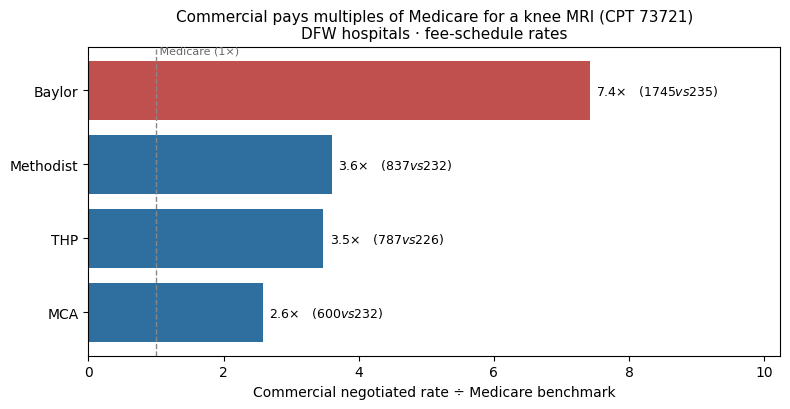

In [14]:
import matplotlib.pyplot as plt

med_comm = comm_clean.groupby('hospital')['dollar_rate'].median()
mc = lad[(lad['lob']=='medicare_advantage') & (lad['methodology_normalized']=='fee schedule')]
med_medicare = mc.groupby('hospital')['dollar_rate'].median()
bench = med_medicare.median()   # common Medicare benchmark, validated by convergence (~$232)

rows = []
for h in med_comm.index:
    denom = med_medicare.get(h, bench)
    denom = bench if pd.isna(denom) else denom
    rows.append((h, med_comm[h], denom, med_comm[h]/denom))
ratio = (pd.DataFrame(rows, columns=['hospital','commercial','medicare','multiple'])
           .sort_values('multiple'))
print(ratio.round({'commercial':0,'medicare':0,'multiple':1}).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.2))
colors = ['#c0504d' if m == ratio['multiple'].max() else '#2f6f9f' for m in ratio['multiple']]
bars = ax.barh(ratio['hospital'], ratio['multiple'], color=colors)
ax.axvline(1.0, color='#888', lw=1, ls='--')
ax.text(1.0, len(ratio)-0.4, ' Medicare (1×)', color='#666', fontsize=8, va='top')
for b, (_, r) in zip(bars, ratio.iterrows()):
    ax.text(b.get_width()+0.1, b.get_y()+b.get_height()/2,
            f"{r['multiple']:.1f}×   (${r['commercial']:.0f} vs ${r['medicare']:.0f})",
            va='center', fontsize=9)
ax.set_xlim(0, ratio['multiple'].max()*1.38)
ax.set_xlabel('Commercial negotiated rate ÷ Medicare benchmark')
ax.set_title('Commercial pays multiples of Medicare for a knee MRI (CPT 73721)\nDFW hospitals · fee-schedule rates',
             fontsize=11)
plt.tight_layout(); plt.show()

In [15]:
# === Step 3 — the full LOB price ladder for CPT 73721 (commercial vs Medicare vs Medicaid) ===

In [16]:
# === Step 0 — build: load the five DuckDBs, classify, materialize `lad` (v4) ===
import sys
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# project-root walk-up so `from src.queries import ...` resolves from anywhere
here = Path.cwd()
for p in [here, *here.parents]:
    if (p / 'src' / 'queries.py').exists():
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        ROOT = p
        break
else:
    raise FileNotFoundError("could not locate src/queries.py by walking up from cwd")

from src.queries import query_procedure_rates_agg, add_lob_v3, add_lob_v4

RAW = ROOT / 'data' / 'raw'
HOSPITAL_FILES = {
    'Baylor':    'baylor_university_medical_center-69947_parsed.duckdb',
    'MCA':       'medical_city_alliance_hospital-77912_parsed.duckdb',
    'Methodist': 'methodist_dallas_medical_center-6000b_parsed.duckdb',
    'Parkland':  'parkland_health-6e88d_parsed.duckdb',
    'THP':       'texas_health_presbyterian_hospital_plano-6ad81_parsed.duckdb',
}
CODE, SETTING = '73721', 'outpatient'

parts = []
for hosp, fname in HOSPITAL_FILES.items():
    con = duckdb.connect(str(RAW / fname), read_only=True)
    try:
        df = query_procedure_rates_agg(con, CODE, SETTING)
    finally:
        con.close()
    df['hospital'] = hosp
    parts.append(df)

all_raw = pd.concat(parts, ignore_index=True)
all_v3  = add_lob_v3(all_raw)        # Day 9 baseline
all_v4  = add_lob_v4(all_raw)        # Decision 19/23 + partial Decision 20
lad     = all_v4.copy()              # Step 3 reads `lad`; v4 reproduces the Day 10 Medicare relabel

print(f"rows: {len(all_v4)}   hospitals: {all_v4['hospital'].nunique()}   "
      f"unknown: {(all_v4['lob']=='unknown').sum()} ({(all_v4['lob']=='unknown').mean():.1%})")
chg = all_v3['lob'] != all_v4['lob']
print(f"\nv3 -> v4 label changes: {chg.sum()} rows")
print(pd.DataFrame({'v3': all_v3.loc[chg,'lob'], 'v4': all_v4.loc[chg,'lob'],
                    'payer_name': all_raw.loc[chg,'payer_name'],
                    'plan_name':  all_raw.loc[chg,'plan_name']}).to_string(index=False))

rows: 278   hospitals: 5   unknown: 6 (2.2%)

v3 -> v4 label changes: 31 rows
                  v3                 v4                                     payer_name                                      plan_name
medicare_traditional medicare_advantage                           Superior Health Plan                                       Medicare
medicare_traditional medicare_advantage                                         Humana                                       Medicare
medicare_traditional medicare_advantage                     WellPoint (fka Amerigroup)                                       Medicare
medicare_traditional medicare_advantage              BCBS MEDICARE MANAGED CARE [7002]              MHS HB MANAGED MEDICARE 106% MDMC
medicare_traditional medicare_advantage                SCOTT AND WHITE MEDICARE [9911]           MHS HB SCOTT AND WHITE MEDICARE MDMC
medicare_traditional medicare_advantage      SOUTHWESTERN HEALTH RESOURCES SWHR [7015]              MHS HB MANAGED MED

=== Median negotiated $ for CPT 73721 (fee schedule), hospital x tier ===
tier       Medicaid  Medicare  Commercial
hospital                                 
Baylor        211.0     235.0      1745.0
Methodist     863.0     232.0       837.0
THP             NaN     226.0       787.0
MCA           209.0       NaN       600.0
Parkland      219.0       NaN         NaN

=== n rows behind each cell ===
tier       Medicaid  Medicare  Commercial
hospital                                 
Baylor            2        11          12
Methodist         5        28          13
THP               0        22           5
MCA              17         0          10
Parkland         19         0           0


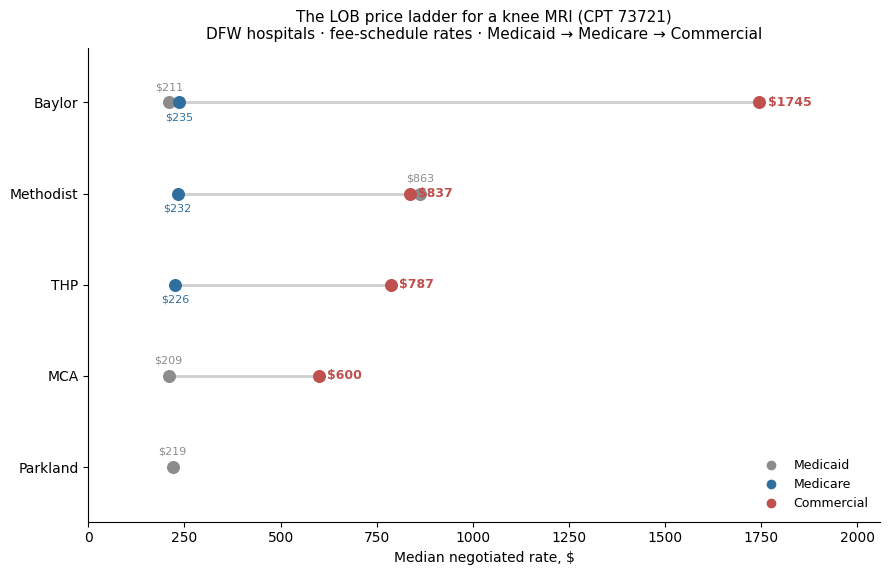

In [17]:
TIER_MAP = {
    'commercial':         'Commercial',
    'medicare_advantage': 'Medicare',
    'medicaid_chip':      'Medicaid', 'medicaid_star':      'Medicaid',
    'medicaid_star_plus': 'Medicaid', 'medicaid_other':     'Medicaid',
}
TIERS  = ['Medicaid', 'Medicare', 'Commercial']          # low -> high rungs
COLORS = {'Medicaid': '#8c8c8c', 'Medicare': '#2f6f9f', 'Commercial': '#c0504d'}

fee = lad[lad['methodology_normalized'] == 'fee schedule'].copy()
fee['tier'] = fee['lob'].map(TIER_MAP)
panel = fee.dropna(subset=['tier'])                      
if 'medicaid_implausible' in panel.columns:          
    panel = panel[~panel['medicaid_implausible']]
tier_med = (panel.groupby(['hospital', 'tier'])['dollar_rate'].median()
                 .unstack('tier').reindex(columns=TIERS))
tier_n   = (panel.groupby(['hospital', 'tier'])['dollar_rate'].size()
                 .unstack('tier').reindex(columns=TIERS))

order = tier_med['Commercial'].sort_values(ascending=False, na_position='last').index
tier_med, tier_n = tier_med.loc[order], tier_n.loc[order]

print("=== Median negotiated $ for CPT 73721 (fee schedule), hospital x tier ===")
print(tier_med.round(0).to_string())
print("\n=== n rows behind each cell ===")
print(tier_n.fillna(0).astype(int).to_string())

fig, ax = plt.subplots(figsize=(9, 0.85*len(tier_med) + 1.6))
for y, (h, r) in enumerate(tier_med.iterrows()):
    vals = r.dropna()
    if len(vals) >= 2:
        ax.plot([vals.min(), vals.max()], [y, y], color='#cfcfcf', lw=2, zorder=1)
    for tier in TIERS:
        if not pd.isna(r[tier]):
            ax.scatter(r[tier], y, s=70, color=COLORS[tier], zorder=3)
    if not pd.isna(r['Medicaid']):
        ax.text(r['Medicaid'], y - 0.22, f"${r['Medicaid']:.0f}", color=COLORS['Medicaid'],
                fontsize=8, ha='center', va='top')
    if not pd.isna(r['Medicare']):
        ax.text(r['Medicare'], y + 0.22, f"${r['Medicare']:.0f}", color=COLORS['Medicare'],
                fontsize=8, ha='center', va='bottom')
    if not pd.isna(r['Commercial']):
        ax.text(r['Commercial'] + ax.get_xlim()[1]*0.012, y, f"${r['Commercial']:.0f}",
                color=COLORS['Commercial'], fontsize=9, ha='left', va='center', fontweight='bold')

ax.set_yticks(range(len(tier_med))); ax.set_yticklabels(tier_med.index)
ax.set_ylim(-0.6, len(tier_med) - 0.4)
ax.set_xlim(0, tier_med.values[~pd.isna(tier_med.values)].max() * 1.18)
ax.set_xlabel('Median negotiated rate, $')
ax.set_title('The LOB price ladder for a knee MRI (CPT 73721)\n'
             'DFW hospitals · fee-schedule rates · Medicaid → Medicare → Commercial', fontsize=11)
handles = [plt.Line2D([0],[0], marker='o', ls='', color=COLORS[t], label=t) for t in TIERS]
ax.legend(handles=handles, loc='lower right', frameon=False, fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.invert_yaxis()
plt.tight_layout(); plt.show()

In [18]:
# === Diagnostic — Methodist Medicaid sub-buckets for CPT 73721 (fee schedule) ===
m = lad[(lad['hospital'] == 'Methodist') &
        (lad['methodology_normalized'] == 'fee schedule') &
        (lad['lob'].str.startswith('medicaid', na=False))].copy()

print("Methodist Medicaid fee-schedule rows:", len(m))
print("\n--- by sub-bucket ---")
print(m.groupby('lob')['dollar_rate'].agg(n='size', median='median', dmin='min', dmax='max')
        .round(0).to_string())
print("\n--- every row ---")
print(m[['lob', 'lob_rule', 'payer_name', 'plan_name', 'billing_class_normalized',
         'dollar_rate', 'dollar_min', 'dollar_max', 'n_charge_ids']]
        .sort_values(['lob', 'dollar_rate']).to_string(index=False))

Methodist Medicaid fee-schedule rows: 5

--- by sub-bucket ---
                    n  median    dmin    dmax
lob                                          
medicaid_chip       1   232.0   232.0   232.0
medicaid_star       1  1076.0  1076.0  1076.0
medicaid_star_plus  3   863.0   200.0   863.0

--- every row ---
               lob                     lob_rule                                     payer_name                             plan_name billing_class_normalized  dollar_rate  dollar_min  dollar_max  n_charge_ids
     medicaid_chip payer_name_ambetter_superior                       AMBETTER SUPERIOR [3051]         MHS HB AMBETTER SUPERIOR MDMC                     None       232.47      232.47      232.47             1
     medicaid_star                    plan_star         WELLPOINT MEDICAID MANAGED CARE [5001]            MHS HB WELLPOINT STAR MDMC                     None      1075.92     1075.92     1075.92             1
medicaid_star_plus               plan_star_plus UNITED HEALTH

In [19]:
import duckdb

con = duckdb.connect(str(RAW / 'methodist_dallas_medical_center-6000b_parsed.duckdb'), read_only=True)
raw = con.execute("""
    SELECT payer_name, plan_name, billing_class_normalized,
           methodology AS methodology_raw, methodology_normalized,
           standard_charge_dollar AS dollar,
           standard_charge_percentage AS pct,
           gross_charge,
           ROUND(standard_charge_dollar / NULLIF(gross_charge, 0) * 100, 1) AS dollar_pct_of_gross
    FROM standard_charge_details
    WHERE (cpt = '73721' OR hcpcs = '73721') AND setting_normalized = 'outpatient'
      AND payer_name ILIKE '%MEDICAID MANAGED CARE%'
    ORDER BY standard_charge_dollar DESC
""").fetchdf()
con.close()

import pandas as pd
pd.set_option('display.width', 200, 'display.max_columns', 20)
print(raw.to_string(index=False))

                                    payer_name                             plan_name billing_class_normalized methodology_raw methodology_normalized  dollar  pct  gross_charge  dollar_pct_of_gross
        WELLPOINT MEDICAID MANAGED CARE [5001]            MHS HB WELLPOINT STAR MDMC                     None    fee schedule           fee schedule 1075.92  NaN        4878.0                 22.1
           MOLINA MEDICAID MANAGED CARE [5005]   MHS HB MEDICAID 110% STAR PLUS MDMC                     None    fee schedule           fee schedule  862.76  NaN        4878.0                 17.7
         SUPERIOR MEDICAID MANAGED CARE [5007]   MHS HB MEDICAID 110% STAR PLUS MDMC                     None    fee schedule           fee schedule  862.76  NaN        4878.0                 17.7
UNITED HEALTHCARE MEDICAID MANAGED CARE [5015] MHS HB UNITED MEDICAID STAR PLUS MDMC                     None    fee schedule           fee schedule  200.30  NaN        4878.0                  4.1


In [20]:
# === Decision 24 — economic-plausibility guard on the Medicaid rung ===
# Medicaid cannot materially exceed Medicare. Rows above MULT x the Medicare
# benchmark are flagged as suspected source-file basis errors (e.g. Methodist's
# "110% STAR PLUS" dollars computed off a non-Medicaid base) and excluded from
# the Medicaid rung — logged here, not silently dropped.
MEDICAID_PLAUSIBILITY_MULT = 2.0

_mc = lad[(lad['lob'] == 'medicare_advantage') &
          (lad['methodology_normalized'] == 'fee schedule')]
medicare_bench   = _mc.groupby('hospital')['dollar_rate'].median().median()   # ~$232
MEDICAID_CEILING = MEDICAID_PLAUSIBILITY_MULT * medicare_bench

lad['medicaid_implausible'] = (
    lad['lob'].str.startswith('medicaid', na=False)
    & (lad['methodology_normalized'] == 'fee schedule')
    & (lad['dollar_rate'] > MEDICAID_CEILING)
)

flagged = lad[lad['medicaid_implausible']]
print(f"Medicare benchmark: ${medicare_bench:,.0f}   "
      f"Medicaid ceiling ({MEDICAID_PLAUSIBILITY_MULT:g}x): ${MEDICAID_CEILING:,.0f}")
print(f"Medicaid rows flagged & excluded from the rung: {len(flagged)}")
print(flagged[['hospital', 'lob', 'payer_name', 'plan_name', 'dollar_rate']]
        .sort_values('dollar_rate', ascending=False).to_string(index=False))

Medicare benchmark: $232   Medicaid ceiling (2x): $465
Medicaid rows flagged & excluded from the rung: 9
 hospital                lob                             payer_name                           plan_name  dollar_rate
Methodist      medicaid_star WELLPOINT MEDICAID MANAGED CARE [5001]          MHS HB WELLPOINT STAR MDMC      1075.92
 Parkland      medicaid_star                       WELLPOINT [1007]             WELLPOINT STAR [100700]       886.70
 Parkland      medicaid_star                          MOLINA [1382]       MOLINA STAR MEDICAID [138204]       886.70
Methodist medicaid_star_plus    MOLINA MEDICAID MANAGED CARE [5005] MHS HB MEDICAID 110% STAR PLUS MDMC       862.76
Methodist medicaid_star_plus  SUPERIOR MEDICAID MANAGED CARE [5007] MHS HB MEDICAID 110% STAR PLUS MDMC       862.76
 Parkland medicaid_star_plus                          MOLINA [1382]           MOLINA STAR PLUS [138200]       854.60
 Parkland      medicaid_star  PARKLAND COMMUNITY HEALTH PLAN [1056]         

In [21]:
import duckdb
con = duckdb.connect(str(RAW / 'parkland_health-6e88d_parsed.duckdb'), read_only=True)
raw = con.execute("""
    SELECT payer_name, plan_name, billing_class_normalized,
           methodology AS methodology_raw, methodology_normalized,
           standard_charge_dollar AS dollar, standard_charge_percentage AS pct,
           gross_charge,
           ROUND(standard_charge_dollar / NULLIF(gross_charge, 0) * 100, 1) AS dollar_pct_of_gross
    FROM standard_charge_details
    WHERE (cpt = '73721' OR hcpcs = '73721') AND setting_normalized = 'outpatient'
      AND (plan_name ILIKE '%STAR%' OR payer_name ILIKE '%MEDICAID%')
    ORDER BY standard_charge_dollar DESC
""").fetchdf()
con.close()
import pandas as pd; pd.set_option('display.width', 220, 'display.max_columns', 20)
print(raw.to_string(index=False))

                           payer_name                                 plan_name billing_class_normalized methodology_raw methodology_normalized  dollar  pct  gross_charge  dollar_pct_of_gross
                        MOLINA [1382]             MOLINA STAR MEDICAID [138204]                 facility    fee schedule           fee schedule   886.7  NaN        6067.0                 14.6
                     WELLPOINT [1007]                   WELLPOINT STAR [100700]                 facility    fee schedule           fee schedule   886.7  NaN        6067.0                 14.6
                        MOLINA [1382]             MOLINA STAR MEDICAID [138204]                 facility    fee schedule           fee schedule   886.7  NaN       12131.0                  7.3
                     WELLPOINT [1007]                   WELLPOINT STAR [100700]                 facility    fee schedule           fee schedule   886.7  NaN        6067.0                 14.6
                        MOLINA [1382]   

In [24]:
mca = all_v4[all_v4['hospital'] == 'MCA']
cols = ['payer_name', 'plan_name', 'payer_group', 'payer_type',
        'methodology_normalized', 'lob', 'lob_rule', 'dollar_rate']


print(mca[mca['lob'] == 'commercial'][cols].sort_values('dollar_rate').to_string())

print(mca.groupby('lob')['dollar_rate'].median())

                       payer_name                         plan_name payer_group  payer_type           methodology_normalized         lob                       lob_rule  dollar_rate
46                         "BCBS"                    "MyBlueHealth"        BCBS  Commercial                     fee schedule  commercial    payer_group_commercial_bcbs       293.63
73                         "BCBS"                "BlueAdvantageHMO"        BCBS  Commercial                     fee schedule  commercial    payer_group_commercial_bcbs       293.63
84                       "United"                      "SmallGroup"       Other       Other                     fee schedule  commercial  payer_name_commercial_carrier       313.62
78                         "BCBS"                     "BluePremier"        BCBS  Commercial                     fee schedule  commercial    payer_group_commercial_bcbs       323.93
83                       "United"                "AllPayerAppendix"       Other       Other    

In [25]:
print(mca.groupby('lob')['dollar_rate'].agg(['count', 'median']).sort_values('median'))


print('\n--- MCA unknown rows ---')
print(mca[mca['lob'] == 'unknown'][['dollar_rate', 'methodology_normalized',
      'payer_name', 'plan_name', 'payer_group', 'lob_rule']]
      .sort_values('dollar_rate').to_string())

                    count   median
lob                               
medicaid_chip           5  208.840
medicaid_star           5  208.840
medicaid_other          5  219.280
medicaid_star_plus      2  220.325
unknown                 1  231.810
aca_exchange            1  313.620
commercial             15  906.530
tpa_self_funded         0      NaN

--- MCA unknown rows ---
    dollar_rate methodology_normalized payer_name  plan_name payer_group  lob_rule
66       231.81           fee schedule   "Molina"  "MCDSTAR"      Molina  no_match


In [26]:
from src.queries import _MEDICAID_STAR_CUE_RE, _MEDICAID_ABBREV_CUE_RE, _strip_quotes
s = _strip_quotes('"MCDSTAR"')
print(repr(s))
print('STAR cue  :', bool(_MEDICAID_STAR_CUE_RE.search(s)))
print('ABBREV cue:', bool(_MEDICAID_ABBREV_CUE_RE.search(s)))

'MCDSTAR'
STAR cue  : False
ABBREV cue: False


In [27]:
print(all_v4['payer_type'].value_counts(dropna=False), '\n')
print(all_v4['methodology_normalized'].value_counts(dropna=False), '\n')
m = all_v4['payer_name'].str.contains('CASH|SELF|UNINSURED|GROSS|DISCOUNT', case=False, na=False)
print('cash/self-pay-ish rows:', m.sum())
print(all_v4.loc[m, ['hospital','payer_name','plan_name','dollar_rate','gross_min','gross_max']].to_string())

payer_type
Commercial    138
Other         123
Medicare       15
Medicaid        2
Name: count, dtype: int64 

methodology_normalized
fee schedule                       181
percent of total billed charges     51
other                               34
per diem                            11
case rate                            1
Name: count, dtype: int64 

cash/self-pay-ish rows: 1
      hospital                                                payer_name                       plan_name  dollar_rate  gross_min  gross_max
105  Methodist  COVID19 HRSA UNINSURED TESTING AND TREATMENT FUND [6005]  MHS HB UNINSURED COVID-19 MDMC       232.47     4878.0     4878.0
